# Q5 Correlation Analysis (Battery Cycle Life)

## Goal
Identify which early-cycle signals are most correlated with cycle life and check multicollinearity.

## Steps
1. Load libraries
2. Load data
3. Convert MATLAB structure → cell rows
4. Feature engineering
5. Correlation analysis
6. Multicollinearity check
7. Model strategy insight


## 1. Library Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import mat73
import scipy.io as sio

from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2. Data Load Function

In [2]:
def load_mat(path):

    try:
        data = mat73.loadmat(path)
        print("Loaded with mat73:", path.name)

    except:

        data = sio.loadmat(
            path,
            simplify_cells=True
        )

        print("Loaded with scipy:", path.name)

    return data

## 3. Convert MATLAB batch → cell rows

MATLAB stores cells as column structure.
We convert to row structure.


In [3]:
def extract_cells(batch):

    cells=[]

    n=len(batch['cycle_life'])

    for i in range(n):

        cell={}

        for key in batch.keys():

            value=batch[key]

            if isinstance(value,list):

                cell[key]=value[i]

            else:

                cell[key]=value

        cells.append(cell)

    return cells

## 4. Feature Engineering (Early Cycle Features)

In [5]:
def early_mean(arr,n=20):

    arr=np.array(arr).reshape(-1)

    if len(arr)==0:
        return np.nan

    return np.mean(arr[:n])


def early_delta(arr,n=20):

    arr=np.array(arr).reshape(-1)

    if len(arr)<2:
        return np.nan

    arr=arr[:n]

    return arr[-1]-arr[0]


def build_feature_df(cells):

    rows=[]

    for cell in cells:

        summary=cell['summary']

        row={

        'cycle_life':cell['cycle_life'],

        'IR_mean':early_mean(summary['IR']),

        'QDischarge_mean':early_mean(summary['QDischarge']),

        'Tmax_mean':early_mean(summary['Tmax']),

        'Tavg_mean':early_mean(summary['Tavg']),

        'charge_time_mean':early_mean(summary['chargetime']),

        'IR_delta':early_delta(summary['IR']),

        'QDischarge_delta':early_delta(summary['QDischarge'])

        }

        rows.append(row)

    return pd.DataFrame(rows)

## 5. Load Dataset

In [6]:
DATA_DIR=Path("../data/data-30")

b1=load_mat(DATA_DIR/"2017-05-12_batchdata_updated_struct_errorcorrect.mat")
b2=load_mat(DATA_DIR/"2018-02-20_batchdata_updated_struct_errorcorrect.mat")
b3=load_mat(DATA_DIR/"2018-04-12_batchdata_updated_struct_errorcorrect.mat")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

Loaded with mat73: 2017-05-12_batchdata_updated_struct_errorcorrect.mat


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

Loaded with mat73: 2018-02-20_batchdata_updated_struct_errorcorrect.mat
Loaded with mat73: 2018-04-12_batchdata_updated_struct_errorcorrect.mat


## 6. Create Cells

In [7]:
cells1=extract_cells(b1['batch'])
cells2=extract_cells(b2['batch'])
cells3=extract_cells(b3['batch'])

print(len(cells1))
print(len(cells2))
print(len(cells3))

46
47
46


## 7. Build Feature Tables

In [8]:
df1=build_feature_df(cells1)
df2=build_feature_df(cells2)
df3=build_feature_df(cells3)

df1['batch']='B1'
df2['batch']='B2'
df3['batch']='B3'

df=pd.concat([df1,df2,df3])

df.head()

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta,batch
0,1190.0,0.015914,1.043606,33.713533,30.096830,12.719076,0.016604,1.076428,B1
1,1179.0,0.015200,1.026199,32.616614,29.970057,12.716683,0.016866,1.081858,B1
2,1177.0,0.015044,1.030038,32.972705,30.123564,12.708053,0.016729,1.085557,B1
3,1226.0,0.014668,1.029076,29.275209,28.625404,11.462626,0.016338,1.084910,B1
4,1227.0,0.015017,1.027011,32.652070,29.952887,11.445637,0.016682,1.082725,B1


## 8. Correlation Analysis

In [9]:
features=[

'cycle_life',
'IR_mean',
'QDischarge_mean',
'Tmax_mean',
'Tavg_mean',
'charge_time_mean',
'IR_delta',
'QDischarge_delta'

]

corr=df[features].corr()

corr

,cycle_life,IR_mean,QDischarge_mean,Tmax_mean,Tavg_mean,charge_time_mean,IR_delta,QDischarge_delta
cycle_life,1.000000,-0.013356,-0.275516,-0.015403,0.145275,0.097163,0.036901,0.026849
IR_mean,-0.013356,1.000000,-0.175347,0.041436,0.093685,0.085963,0.078976,0.082143
QDischarge_mean,-0.275516,-0.175347,1.000000,0.096635,0.456772,-0.200792,-0.867969,-0.864274
Tmax_mean,-0.015403,0.041436,0.096635,1.000000,0.090302,-0.026020,-0.101326,-0.098967
Tavg_mean,0.145275,0.093685,0.456772,0.090302,1.000000,-0.185702,-0.711840,-0.714155
charge_time_mean,0.097163,0.085963,-0.200792,-0.026020,-0.185702,1.000000,0.212521,0.207978
IR_delta,0.036901,0.078976,-0.867969,-0.101326,-0.711840,0.212521,1.000000,0.998566
QDischarge_delta,0.026849,0.082143,-0.864274,-0.098967,-0.714155,0.207978,0.998566,1.000000


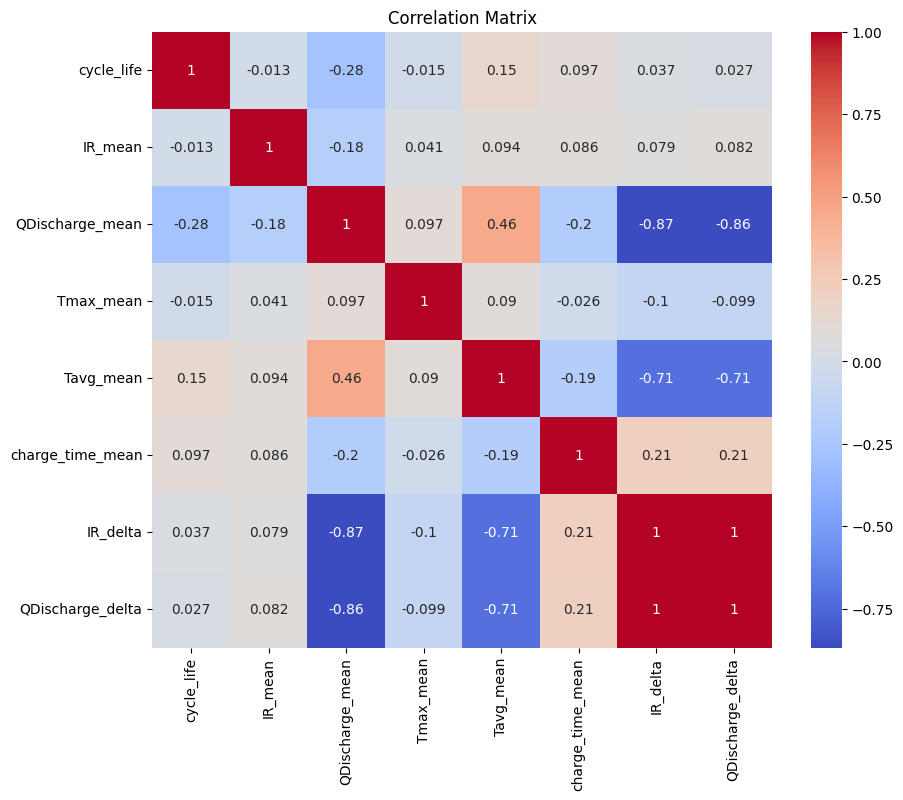

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
corr,
annot=True,
cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

## 9. Strongest Feature

In [11]:
target_corr=corr['cycle_life']

target_corr=target_corr.drop('cycle_life')

target_corr.sort_values()

QDischarge_mean    -0.275516
Tmax_mean          -0.015403
IR_mean            -0.013356
QDischarge_delta    0.026849
IR_delta            0.036901
charge_time_mean    0.097163
Tavg_mean           0.145275
Name: cycle_life, dtype: float64

In [12]:
best_feature=target_corr.abs().idxmax()

best_value=target_corr[best_feature]

print(best_feature)
print(best_value)

QDischarge_mean
-0.2755164755973123


## 10. Multicollinearity Check

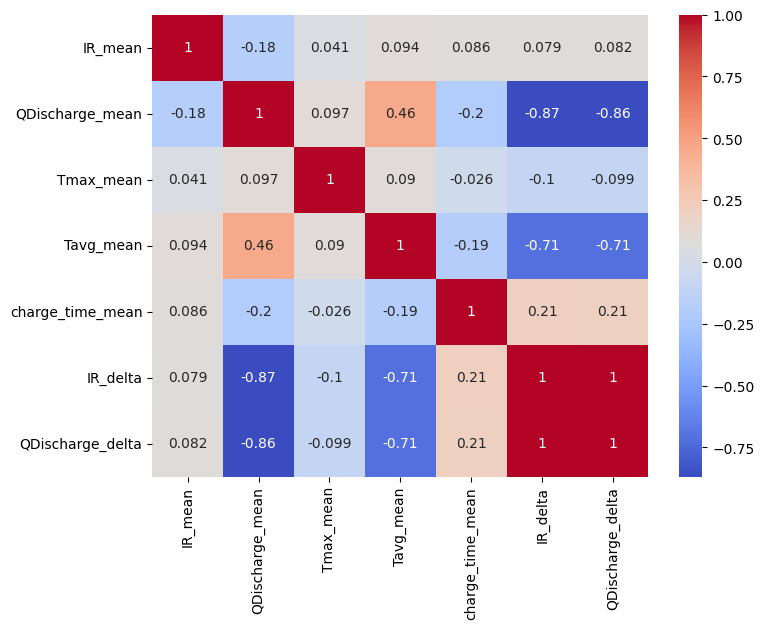

In [13]:
X=df[[
'IR_mean',
'QDischarge_mean',
'Tmax_mean',
'Tavg_mean',
'charge_time_mean',
'IR_delta',
'QDischarge_delta'
]].dropna()

plt.figure(figsize=(8,6))

sns.heatmap(
X.corr(),
annot=True,
cmap='coolwarm'
)

plt.show()

In [14]:
vif=pd.DataFrame()

vif['feature']=X.columns

vif['VIF']=[

variance_inflation_factor(X.values,i)

for i in range(X.shape[1])

]

vif.sort_values('VIF',ascending=False)

,feature,VIF
3,Tavg_mean,539.628171
6,QDischarge_delta,539.358832
1,QDischarge_mean,530.498499
5,IR_delta,520.531361
0,IR_mean,19.193535
4,charge_time_mean,12.600099
2,Tmax_mean,2.568624


## 11. Model Strategy Insight

Based on correlation:

Use early cycle features.

Remove highly correlated features.

Tree models recommended:
- RandomForest
- XGBoost

Possible pipeline:

Feature engineering → Feature selection → Model training
